# Debug 2

In [23]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from nik_io import load_event, load_cartesian_kspace
from nik_train import prepare_tensors
from nik_recon import (
    ifft1d_kz_to_z, ifft1d_kz_to_z_cartesian,
    make_multicoil_radial_dataset, make_multicoil_cartesian_dataset,
)
from kspace_normalization import compute_dcf_radial, KSpaceNormalizer
from nik_model import NIK_MRI_SIREN_REIM
from nik_loss import HDRLossFF

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


## Manual params

In [24]:
radial_file = '/scratch/rnga/vvpshenov/XCAT-ERIC/results/simulation_results_20260326T114914_rad.mat'
cart_file   = '/scratch/rnga/vvpshenov/XCAT-ERIC/results/simulation_results_20260326T113845_cart.mat'
t_frame = 0
coil_idx = 0
z_slice_raw = -1
subsample_frac = 0.7
seed = 0

# nik_mri siren params 
feature_dim = 128
num_layers  = 6
out_dim     = 1              
omega_0     = 30.0
ff_scale    = 1.0

# hdr loss
hdr_eps  = 1e-2
hdr_sigma = 1.0
hdr_lambda = 0.5 # ???   commented out in the code, set to 0     

# training
lr           = 3e-5
adam_b1      = 0.9
adam_b2      = 0.999
adam_eps     = 1e-8
weight_decay = 0.0
steps        = 30000
batch_size   = None # None for full data size            
grad_clip    = None

torch.manual_seed(seed); np.random.seed(seed)

## Raw radial load

In [25]:
event = load_event(radial_file, load_images=True, load_coil_maps=True)
k_np  = np.transpose(event['k'],    (0, 2, 1, 3))
traj_np = np.transpose(event['traj'], (0, 2, 1, 3))
T, S, C, RO = k_np.shape
print('k_np:',    k_np.shape,    k_np.dtype)
print('traj_np:', traj_np.shape, traj_np.dtype)
print('T,S,C,RO =', T, S, C, RO)
if event.get('coil_maps') is not None:
    print('coil_maps radial:', event['coil_maps'].shape, event['coil_maps'].dtype)
if event.get('gt_img') is not None:
    print('gt_img radial:', event['gt_img'].shape, event['gt_img'].dtype)

k_np: (5, 2343, 8, 312) complex64
traj_np: (5, 2343, 3, 312) float32
T,S,C,RO = 5 2343 8 312
coil_maps radial: (8, 11, 312, 312) float64
gt_img radial: (61, 11, 312, 214) float32


In [26]:
#print(traj_np)

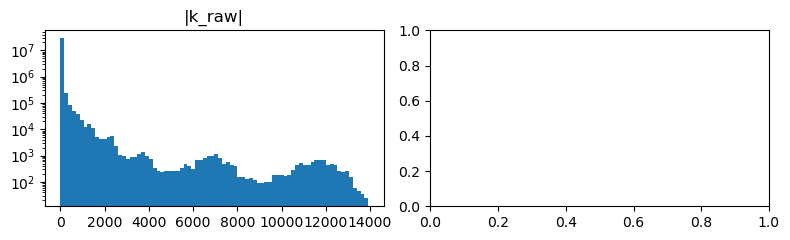

In [27]:
# raw k magnitude
fig, ax = plt.subplots(1, 2, figsize=(8, 2.5))
ax[0].hist(np.abs(k_np).ravel(), bins=80); ax[0].set_title('|k_raw|'); ax[0].set_yscale('log')
#ax[1].hist(traj_np.ravel(), bins=80);     ax[1].set_title('traj raw')
plt.tight_layout(); plt.show()

## Tensors + scales

In [28]:
# _t for tensors
k_t, traj_t, scales, dims, k_scale = prepare_tensors(k_np, traj_np, data_device=device)
print('k_t:',    k_t.shape,    k_t.dtype,    k_t.device)
print('traj_t:', traj_t.shape, traj_t.dtype)
sx, sy, sz = [float(s) for s in scales]
print(f'scales sx={sx:.4f} sy={sy:.4f} sz={sz:.4f}')
print(f'k_scale={float(k_scale):.4f}')

k_t: torch.Size([5, 2343, 8, 312]) torch.complex64 cuda:0
traj_t: torch.Size([5, 2343, 3, 312]) torch.float32
scales sx=0.5000 sy=0.5000 sz=11.0000
k_scale=56.6607


In [29]:
#print(traj_t)

## Post kz -> z IFFT

k_img_space: torch.Size([5, 213, 8, 11, 312]) torch.complex64
n_z_slices, n_ro_per_slice, z_slice_idx = 11 213 5


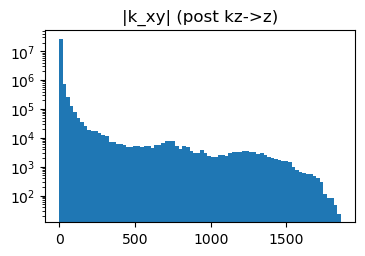

In [30]:
k_img_space, n_z_slices, n_ro_per_slice, _ = ifft1d_kz_to_z(k_t, traj_t, t_frame=t_frame)
z_slice_idx = n_z_slices // 2 if z_slice_raw == -1 else int(z_slice_raw)
print('k_img_space:', k_img_space.shape, k_img_space.dtype)
print('n_z_slices, n_ro_per_slice, z_slice_idx =', n_z_slices, n_ro_per_slice, z_slice_idx)

_vals = torch.abs(k_img_space).flatten().cpu().numpy()
plt.figure(figsize=(4,2.5)); plt.hist(_vals, bins=80); plt.yscale('log')
plt.title('|k_xy| (post kz->z)'); plt.show()

## Radial single-coil dataset

x_all: torch.Size([66456, 4]) torch.float32
y_all_raw: torch.Size([66456, 2]) torch.float32 (coil=0)
spoke_id_all: torch.Size([66456])   unique: 213


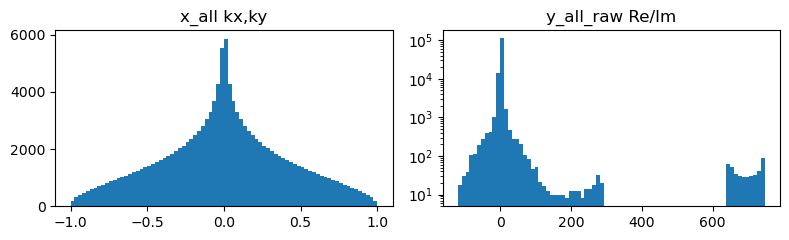

In [31]:
x_all, y_all_mc, spoke_id_all, ro_id_all, meta = make_multicoil_radial_dataset(
    k_img_space, traj_t, scales, dims,
    t_fixed=t_frame, z_slice_idx=z_slice_idx,
    n_slices=n_z_slices, compute_device=device,
)
# single coil slice
y_all_raw = y_all_mc[:, 2*coil_idx:2*coil_idx+2].contiguous()
print('x_all:',        x_all.shape,        x_all.dtype)
print('y_all_raw:',    y_all_raw.shape,    y_all_raw.dtype, f'(coil={coil_idx})')
print('spoke_id_all:', spoke_id_all.shape, '  unique:', int(spoke_id_all.max())+1)

fig, ax = plt.subplots(1, 2, figsize=(8, 2.5))
ax[0].hist(x_all[:, :2].flatten().cpu().numpy(), bins=80); ax[0].set_title('x_all kx,ky')
ax[1].hist(y_all_raw.flatten().cpu().numpy(),     bins=80); ax[1].set_title('y_all_raw Re/Im'); ax[1].set_yscale('log')
plt.tight_layout(); plt.show()

### Radial NUFFT recon (one frame/coil, measured only)

img_rad: (312, 312) complex64


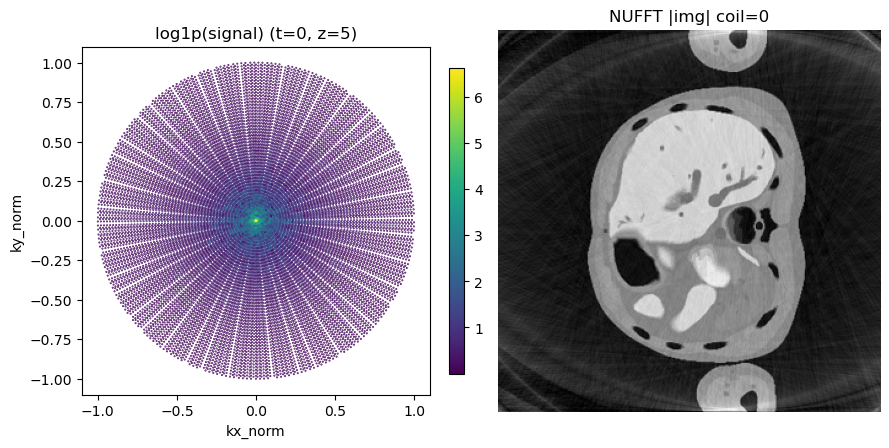

In [32]:
from nik_recon import nufft2d_recon

img_rad = nufft2d_recon(
    k_img_space, traj_t,
    t_frame=t_frame, coil_idx=coil_idx, z_slice_idx=z_slice_idx,
    scales=scales, img_size=(312, 312), n_slices=n_z_slices,
    return_complex=True,
)
print('img_rad:', img_rad.shape, img_rad.dtype)

# k-space scatter (subsampled) + NUFFT magnitude
kx_np = x_all[:, 0].cpu().numpy()
ky_np = x_all[:, 1].cpu().numpy()
mag   = np.abs(y_all_raw[:, 0].cpu().numpy() + 1j * y_all_raw[:, 1].cpu().numpy())

step = max(1, len(kx_np) // 20000)
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
sc = ax[0].scatter(kx_np[::step], ky_np[::step], s=0.2,
                   c=np.log1p(mag[::step]), cmap='viridis')
ax[0].set_aspect('equal'); ax[0].set_title(f'log1p(signal) (t={t_frame}, z={z_slice_idx})')
ax[0].set_xlabel('kx_norm'); ax[0].set_ylabel('ky_norm')
plt.colorbar(sc, ax=ax[0], fraction=0.04)
ax[1].imshow(np.abs(img_rad), cmap='gray')
ax[1].set_title(f'NUFFT |img| coil={coil_idx}'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## Cartesian reference

In [33]:
cart_event = load_cartesian_kspace(cart_file, load_images=True, load_coil_maps=True)
k_cart_t = torch.from_numpy(cart_event['k_cart'].astype(np.complex64)).to(device)
print('(T=.., C=.., kz=.., ky=.., kx=..)')
print('k_cart_t:', k_cart_t.shape, k_cart_t.dtype)


k_cart_z = ifft1d_kz_to_z_cartesian(k_cart_t)
print('k_cart_z:', k_cart_z.shape)
z_cart = k_cart_z.shape[2] // 2 if z_slice_raw == -1 else int(z_slice_raw)

x_cart, y_cart_mc, meta_cart = make_multicoil_cartesian_dataset(
    k_cart_z, t_fixed=min(t_frame, k_cart_z.shape[0]-1),
    z_slice_idx=z_cart, scales_radial=scales, compute_device=device,
)
# single coil slice
y_cart_raw = y_cart_mc[:, 2*coil_idx:2*coil_idx+2].contiguous()
print('x_cart:',     x_cart.shape)

print('y_cart_raw:', y_cart_raw.shape, f'(coil={coil_idx})')
print('meta_cart:',  meta_cart)

(T=.., C=.., kz=.., ky=.., kx=..)
k_cart_t: torch.Size([4, 8, 11, 214, 312]) torch.complex64
k_cart_z: torch.Size([4, 8, 11, 214, 312])
x_cart: torch.Size([66768, 2])
y_cart_raw: torch.Size([66768, 2]) (coil=0)
meta_cart: {'nky': 214, 'nkx': 312, 'nz': 11, 'n_coils': 8, 't_fixed': 0, 'z_slice_idx': 5, 'N': 66768}


### Coil sensitivity maps (all coils, middle z-slice)

sens_rad: (8, 312, 312)   sens_cart: (8, 312, 214)
  coil 0: rad min/max = 0.3274/0.3274   cart min/max = 0.3274/0.3274
  coil 1: rad min/max = 0.1457/0.4683   cart min/max = 0.1457/0.4682
  coil 2: rad min/max = 0.0000/0.5000   cart min/max = 0.0000/0.5000
  coil 3: rad min/max = 0.1746/0.4783   cart min/max = 0.1749/0.4783
  coil 4: rad min/max = 0.3779/0.3779   cart min/max = 0.3779/0.3779
  coil 5: rad min/max = 0.1751/0.4783   cart min/max = 0.1754/0.4783
  coil 6: rad min/max = 0.0025/0.5000   cart min/max = 0.0025/0.5000
  coil 7: rad min/max = 0.1459/0.4685   cart min/max = 0.1459/0.4684


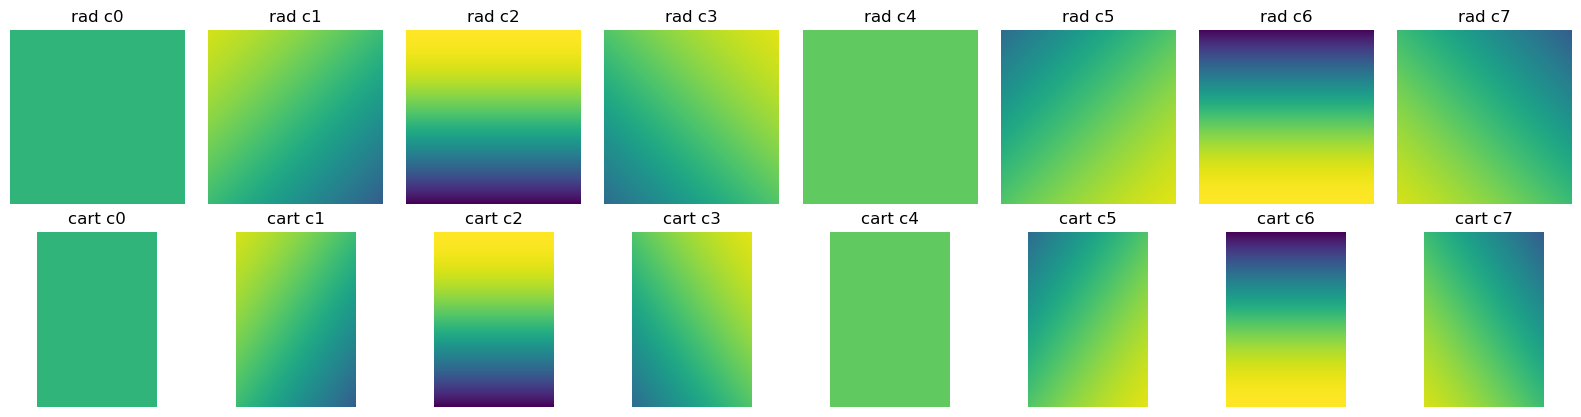

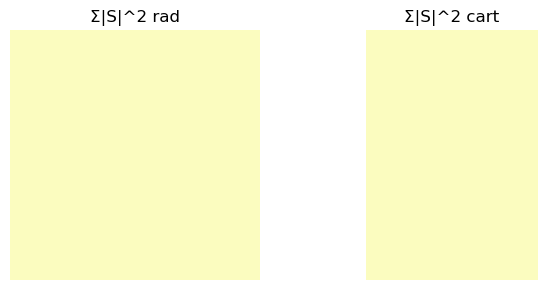

0.9999999999999998
1.0000000000000002


In [34]:
sens_rad  = event['coil_maps'][:, z_slice_idx, :, :]         
sens_cart = cart_event['coil_maps'][:, z_cart, :, :]         
print('sens_rad:', sens_rad.shape, '  sens_cart:', sens_cart.shape)
for c in range(C):
    print(f'  coil {c}: rad min/max = {float(sens_rad[c].min()):.4f}/{float(sens_rad[c].max()):.4f}   '
          f'cart min/max = {float(sens_cart[c].min()):.4f}/{float(sens_cart[c].max()):.4f}')

# shared scale across all panels
vmin = float(min(sens_rad.min(),  sens_cart.min()))
vmax = float(max(sens_rad.max(),  sens_cart.max()))

fig, ax = plt.subplots(2, C, figsize=(2*C, 4.2))
for c in range(C):
    ax[0, c].imshow(np.abs(sens_rad[c]),  cmap='viridis', vmin=vmin, vmax=vmax); ax[0, c].set_title(f'rad c{c}');  ax[0, c].axis('off')
    ax[1, c].imshow(np.abs(sens_cart[c]), cmap='viridis', vmin=vmin, vmax=vmax); ax[1, c].set_title(f'cart c{c}'); ax[1, c].axis('off')
plt.tight_layout(); plt.show()

# sum |S|^2 - denom
rss_rad  = np.sum(np.abs(sens_rad)**2,  axis=0)
rss_cart = np.sum(np.abs(sens_cart)**2, axis=0)
vmax2 = float(max(rss_rad.max(), rss_cart.max()))

fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].imshow(rss_rad,  cmap='magma', vmin=0, vmax=vmax2); ax[0].set_title('Σ|S|^2 rad');  ax[0].axis('off')
ax[1].imshow(rss_cart, cmap='magma', vmin=0, vmax=vmax2); ax[1].set_title('Σ|S|^2 cart'); ax[1].axis('off')
plt.tight_layout(); plt.show()

print(rss_rad.min())
print(rss_rad.max())

In [35]:
# check coil sens maps only real
import h5py
with h5py.File(cart_file, 'r') as f:
    d = f['/results/kspace/coilMaps']
    print('raw dtype:', d.dtype, '  shape:', d.shape)
    sample = d[0, 0, 0, 0]
    print('sample:', sample)     


raw dtype: float64   shape: (8, 11, 312, 214)
sample: 0.49491072094046634


## Train / heldout spoke split

In [36]:
if subsample_frac < 1.0:
    n_spokes = int(spoke_id_all.max().item()) + 1
    n_train_spokes = max(1, int(n_spokes * subsample_frac))
    g = torch.Generator(device=spoke_id_all.device).manual_seed(seed)
    perm = torch.randperm(n_spokes, generator=g, device=spoke_id_all.device)
    train_spokes = perm[:n_train_spokes]
    train_mask   = torch.isin(spoke_id_all, train_spokes)
    train_idx    = torch.where(train_mask)[0]
    heldout_idx  = torch.where(~train_mask)[0]
    print(f'spokes {n_train_spokes}/{n_spokes} ({subsample_frac:.0%})   '
          f'train pts {int(train_mask.sum())}   heldout pts {int((~train_mask).sum())}')
else:
    n_spokes = int(spoke_id_all.max().item()) + 1
    train_mask  = torch.ones_like(spoke_id_all, dtype=torch.bool)
    train_idx   = torch.arange(spoke_id_all.numel(), device=spoke_id_all.device)
    heldout_idx = torch.empty(0, dtype=torch.long, device=spoke_id_all.device)
    print(f'full radial, no heldout   train pts {spoke_id_all.numel()}')

spokes 149/213 (70%)   train pts 46488   heldout pts 19968


## Normalization

y_max = 751.3658   (max |c| over 46488 train pts)
y_all: torch.Size([66456, 2])
y_cart: torch.Size([66768, 2])


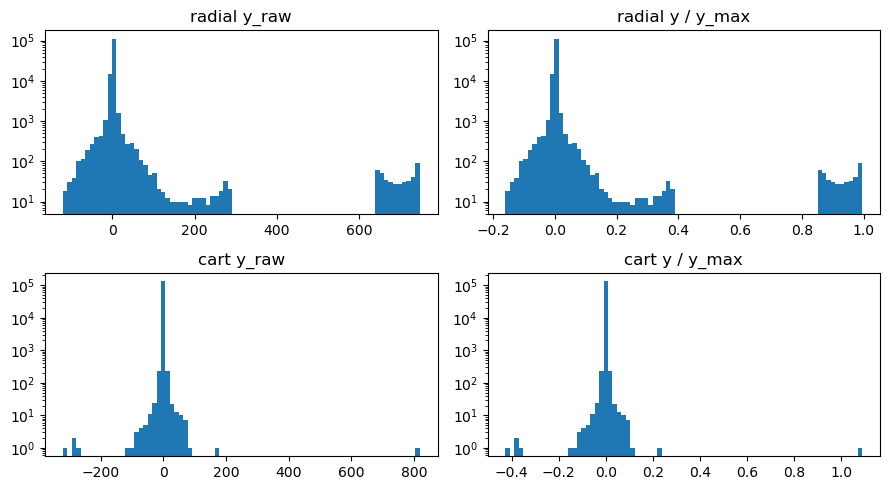

In [37]:
# nik_mri-style, divide by max |amplit| over training points
y_complex_train = torch.complex(y_all_raw[train_idx, 0], y_all_raw[train_idx, 1])
y_max = float(y_complex_train.abs().amax())
y_all  = (y_all_raw  / y_max).contiguous()
y_cart = (y_cart_raw / y_max).contiguous()
print(f'y_max = {y_max:.4f}   (max |c| over {int(train_mask.sum())} train pts)')
print('y_all:',  y_all.shape)
print('y_cart:', y_cart.shape)

fig, ax = plt.subplots(2, 2, figsize=(9, 5))
ax[0, 0].hist(y_all_raw.flatten().cpu().numpy(),  bins=80); ax[0, 0].set_title('radial y_raw');           ax[0, 0].set_yscale('log')
ax[0, 1].hist(y_all.flatten().cpu().numpy(),      bins=80); ax[0, 1].set_title('radial y / y_max');      ax[0, 1].set_yscale('log')
ax[1, 0].hist(y_cart_raw.flatten().cpu().numpy(), bins=80); ax[1, 0].set_title('cart y_raw');            ax[1, 0].set_yscale('log')
ax[1, 1].hist(y_cart.flatten().cpu().numpy(),     bins=80); ax[1, 1].set_title('cart y / y_max');        ax[1, 1].set_yscale('log')
plt.tight_layout(); plt.show()

## Model

In [38]:
# nik_mri coord order: [t, coil, kx, ky]
t_val    = float(2.0 * t_frame / (T - 1) - 1.0)                   
coil_val = float(torch.linspace(-1.0, 1.0, C)[coil_idx].item())   
print(f't_val={t_val:.3f}   coil_val={coil_val:.3f}')

def to_nikmri_coords(kxy):
    # kxy: (N, 2) [kx_norm, ky_norm]  ->  (N, 4) [t, coil, kx, ky]
    n = kxy.shape[0]
    t_col    = torch.full((n, 1), t_val,    dtype=kxy.dtype, device=kxy.device)
    coil_col = torch.full((n, 1), coil_val, dtype=kxy.dtype, device=kxy.device)
    return torch.cat([t_col, coil_col, kxy], dim=1)

model = NIK_MRI_SIREN_REIM(
    coord_dim=4,
    feature_dim=feature_dim,
    num_layers=num_layers,
    out_dim=out_dim,
    omega_0=omega_0,
    ff_scale=ff_scale,
    ff_seed=seed,
).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'params: {n_params}')

with torch.no_grad():
    x_probe = to_nikmri_coords(x_all[:8, :2].to(device))
    y_probe = model(x_probe)
print('model in :', x_probe.shape, x_probe.dtype)
print('model out:', y_probe.shape, y_probe.dtype, '(complex)')

t_val=-1.000   coil_val=-1.000
params: 99330
model in : torch.Size([8, 4]) torch.float32
model out: torch.Size([8, 1]) torch.complex64 (complex)


## Training

train pts 46488   heldout pts 19968
cart val: 52016/66768 pts inside disk
step     1  train 8.093e+00  reg 7.040e-03
step   100  train 9.362e-01  reg 1.777e-04  cart 4.143e-02  held 9.471e-01
step   200  train 4.739e-01  reg 2.271e-04  cart 4.583e-02  held 4.996e-01
step   300  train 3.678e-01  reg 1.330e-04  cart 4.416e-02  held 3.861e-01
step   400  train 3.284e-01  reg 1.086e-04  cart 4.359e-02  held 3.452e-01
step   500  train 3.122e-01  reg 1.230e-04  cart 4.330e-02  held 3.256e-01
step   600  train 3.048e-01  reg 7.829e-05  cart 4.038e-02  held 3.171e-01
step   700  train 6.192e-01  reg 4.303e-04  cart 5.702e-02  held 6.328e-01
step   800  train 3.491e-01  reg 1.078e-04  cart 4.184e-02  held 3.643e-01
step   900  train 3.053e-01  reg 9.925e-05  cart 4.177e-02  held 3.147e-01
step  1000  train 2.892e-01  reg 6.438e-05  cart 3.975e-02  held 3.078e-01
step  1100  train 2.745e-01  reg 5.860e-05  cart 3.826e-02  held 2.913e-01
step  1200  train 5.493e-01  reg 4.333e-04  cart 5.894e-02

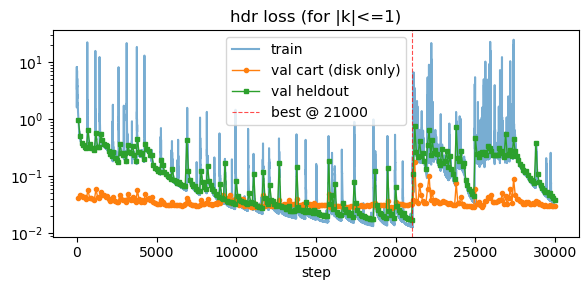

In [39]:
import torch.nn.functional as F

x_all_2d  = x_all[:, :2].to(device)
y_all_dev = y_all.to(device)

# reuse train_idx / heldout_idx computed earlier 
x_train_kxy = x_all_2d[train_idx];  y_train = y_all_dev[train_idx]
if heldout_idx.numel() > 0:
    x_held_kxy = x_all_2d[heldout_idx]; y_held = y_all_dev[heldout_idx]
else:
    x_held_kxy, y_held = None, None
print(f'train pts {x_train_kxy.shape[0]}   heldout pts {0 if x_held_kxy is None else x_held_kxy.shape[0]}')

x_train = to_nikmri_coords(x_train_kxy)
x_held  = to_nikmri_coords(x_held_kxy) if x_held_kxy is not None else None
x_cart_full = to_nikmri_coords(x_cart.to(device))
y_cart_full = y_cart.to(device)

# disk mask, model only trained inside |k| <= 1
cart_disk_mask = (x_cart_full[:, 2]**2 + x_cart_full[:, 3]**2) <= 1.0
x_cart_v = x_cart_full[cart_disk_mask]
y_cart_v = y_cart_full[cart_disk_mask]
print(f'cart val: {int(cart_disk_mask.sum())}/{x_cart_full.shape[0]} pts inside disk')

def to_complex_target(y_real):
    return torch.complex(y_real[:, 0], y_real[:, 1]).unsqueeze(-1)

y_train_c = to_complex_target(y_train)
y_held_c  = to_complex_target(y_held)  if y_held is not None else None
y_cart_vc = to_complex_target(y_cart_v)

N = x_train.shape[0]
opt = torch.optim.Adam(
    model.parameters(), lr=lr,
    betas=(adam_b1, adam_b2), eps=adam_eps,
    weight_decay=weight_decay,
)
criterion = HDRLossFF(sigma=hdr_sigma, eps=hdr_eps, factor=hdr_lambda)

model.train()
eval_every = 100
train_losses, reg_losses, steps_v, val_cart, val_held = [], [], [], [], []
best_val, best_step, best_state = float('inf'), -1, None

for step in range(1, steps + 1):
    if batch_size is None or batch_size >= N:
        x, y, coords = x_train, y_train_c, x_train
    else:
        idx = torch.randint(0, N, (batch_size,), device=device)
        x, y, coords = x_train[idx], y_train_c[idx], x_train[idx]

    opt.zero_grad(set_to_none=True)
    y_pred = model(x)
    loss, reg = criterion(y_pred, y, coords)
    loss.backward()
    if grad_clip is not None:
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    opt.step()
    train_losses.append(float(loss.item()))
    reg_losses.append(float(reg.item()))

    if step % eval_every == 0 or step == steps:
        model.eval()
        with torch.no_grad():
            vc, _ = criterion(model(x_cart_v), y_cart_vc, x_cart_v)
            val_cart.append(float(vc.item()))
            if x_held is not None:
                vh, _ = criterion(model(x_held), y_held_c, x_held)
                val_held.append(float(vh.item()))
        steps_v.append(step)
        model.train()
        # track best by cart val
        if val_held[-1] < best_val:
            best_val  = val_held[-1]
            best_step = step
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if step % 100 == 0 or step == 1:
        msg = f'step {step:5d}  train {train_losses[-1]:.3e}  reg {reg_losses[-1]:.3e}'
        if val_cart: msg += f'  cart {val_cart[-1]:.3e}'
        if val_held: msg += f'  held {val_held[-1]:.3e}'
        print(msg)

if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print(f'\nrestored best: step {best_step}   cart_val {best_val:.3e}')

plt.figure(figsize=(6, 3))
plt.plot(train_losses, label='train', alpha=0.6)
plt.plot(steps_v, val_cart, 'o-', label='val cart (disk only)', lw=1, ms=3)
if val_held:
    plt.plot(steps_v, val_held, 's-', label='val heldout', lw=1, ms=3)
if best_step > 0:
    plt.axvline(best_step, color='r', ls='--', lw=0.8, alpha=0.7, label=f'best @ {best_step}')
plt.yscale('log'); plt.xlabel('step'); plt.legend(); plt.title('hdr loss (for |k|<=1)')
plt.tight_layout(); plt.show()

## Predict + FFT (single coil)

In [40]:
nky, nkx = meta_cart['nky'], meta_cart['nkx']
x_cart_d = to_nikmri_coords(x_cart.to(device))
y_cart_d = y_cart.to(device)

# disk mask: zero out  predictions outside |k| <= 1 
disk_mask = (x_cart_d[:, 2]**2 + x_cart_d[:, 3]**2) <= 1.0

model.eval()
with torch.no_grad():
    cart_pred_complex = model(x_cart_d).squeeze(-1)              
    cart_pred_complex = torch.where(disk_mask, cart_pred_complex,
                                    torch.zeros_like(cart_pred_complex))
    cart_pred_ri = torch.stack([cart_pred_complex.real,
                                cart_pred_complex.imag], dim=1)   
    # rescale to physical : multiply by the same y_max used for normalization
    cart_pred_denorm = cart_pred_ri * y_max
    y_meas_denorm    = y_cart_d    * y_max

print(f'pred zeroed: {int((~disk_mask).sum())}/{disk_mask.numel()} pts outside disk')
print('cart_pred_ri:',     cart_pred_ri.shape)
print('cart_pred_denorm:', cart_pred_denorm.shape)
print('y_meas_denorm:',    y_meas_denorm.shape)
print(f'grid nky x nkx = {nky} x {nkx}')

k_pred = torch.complex(cart_pred_denorm[:, 0], cart_pred_denorm[:, 1]).reshape(nky, nkx)
k_meas = torch.complex(y_meas_denorm[:, 0],    y_meas_denorm[:, 1]).reshape(nky, nkx)
img_pred_c = torch.fft.fftshift(torch.fft.ifft2(k_pred)).cpu().numpy().T
img_meas_c = torch.fft.ifft2(k_meas).cpu().numpy().T
print('img_pred_c:', img_pred_c.shape, img_pred_c.dtype)
print('img_meas_c:', img_meas_c.shape, img_meas_c.dtype)

pred zeroed: 14752/66768 pts outside disk
cart_pred_ri: torch.Size([66768, 2])
cart_pred_denorm: torch.Size([66768, 2])
y_meas_denorm: torch.Size([66768, 2])
grid nky x nkx = 214 x 312
img_pred_c: (312, 214) complex64
img_meas_c: (312, 214) complex64


## k-space fit check (pred line vs measured points)

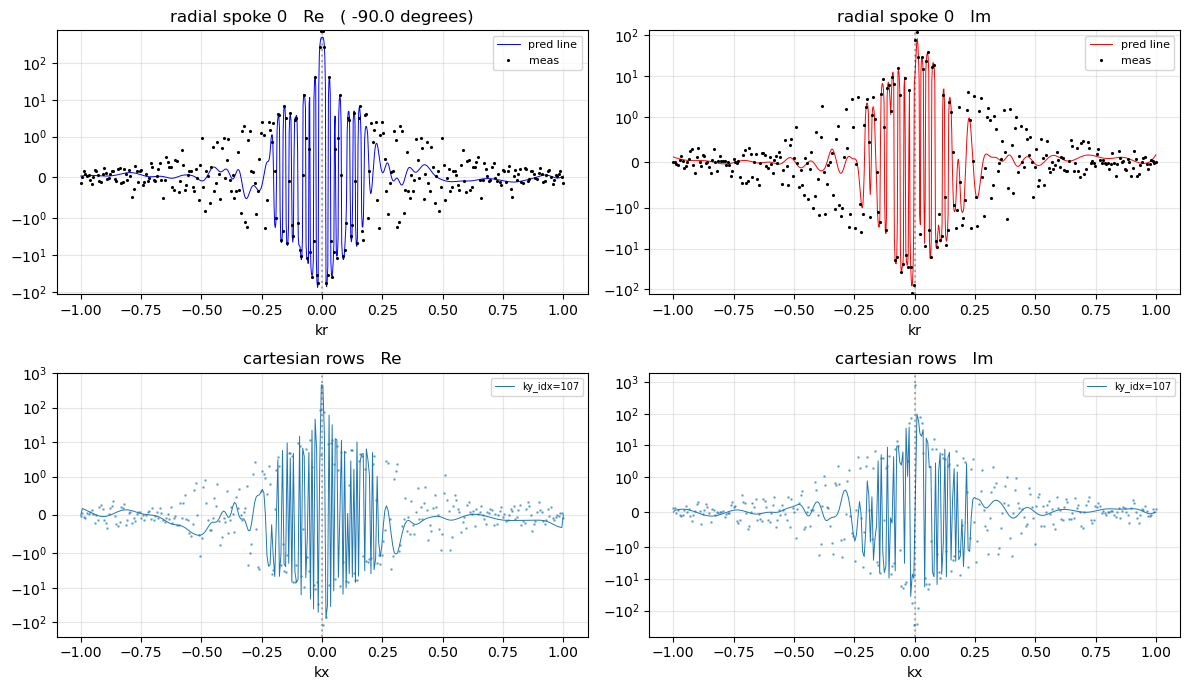

In [41]:
spoke_idx_plot = 0
n_line_pts     = 800
row_offsets    = [ 0]
row_colors     = ['C0', 'C1', 'C2']

#  radial spoke
m_sp  = (spoke_id_all == spoke_idx_plot).cpu().numpy()
sp_kx = x_all[m_sp, 0].cpu().numpy()
sp_ky = x_all[m_sp, 1].cpu().numpy()
sp_y  = y_all_raw[m_sp].cpu().numpy()
far = int(np.argmax(sp_kx**2 + sp_ky**2))
sp_angle = float(np.arctan2(sp_ky[far], sp_kx[far]))
sp_kr = sp_kx * np.cos(sp_angle) + sp_ky * np.sin(sp_angle)
order = np.argsort(sp_kr)
sp_kr   = sp_kr[order]
sp_re_m = sp_y[order, 0]
sp_im_m = sp_y[order, 1]

# radial spoke
kr_dense = np.linspace(sp_kr.min(), sp_kr.max(), n_line_pts).astype(np.float32)
kx_dense = (kr_dense * np.cos(sp_angle)).astype(np.float32)
ky_dense = (kr_dense * np.sin(sp_angle)).astype(np.float32)
coords_2d = torch.from_numpy(np.stack([kx_dense, ky_dense], axis=1)).float().to(device)
coords_4d = to_nikmri_coords(coords_2d)
model.eval()
with torch.no_grad():
    pc  = model(coords_4d).squeeze(-1)
    pri = torch.stack([pc.real, pc.imag], dim=1)
    pd  = (pri * y_max).cpu().numpy()                # rescale to physical 
sp_re_p, sp_im_p = pd[:, 0], pd[:, 1]

#  cartesian rows
x_cart_grid = x_cart.reshape(nky, nkx, 2).cpu().numpy()
y_cart_grid = y_cart_raw.reshape(nky, nkx, 2).cpu().numpy()
pred_grid   = cart_pred_denorm.reshape(nky, nkx, 2).cpu().numpy()

fig, ax = plt.subplots(2, 2, figsize=(12, 7))

ax[0, 0].plot(kr_dense, sp_re_p, 'b-',  lw=0.7, label='pred line')
ax[0, 0].plot(sp_kr,    sp_re_m, 'k.',  ms=2.5, label='meas')
ax[0, 0].set_title(f'radial spoke {spoke_idx_plot}   Re   ( {np.degrees(sp_angle):.1f} degrees)')
ax[0, 0].set_xlabel('kr'); ax[0, 0].axvline(0, color='k', ls=':', alpha=0.3)
ax[0, 0].grid(alpha=0.3); ax[0, 0].legend(fontsize=8)

ax[0, 1].plot(kr_dense, sp_im_p, 'r-',  lw=0.7, label='pred line')
ax[0, 1].plot(sp_kr,    sp_im_m, 'k.',  ms=2.5, label='meas')
ax[0, 1].set_title(f'radial spoke {spoke_idx_plot}   Im')
ax[0, 1].set_xlabel('kr'); ax[0, 1].axvline(0, color='k', ls=':', alpha=0.3)
ax[0, 1].grid(alpha=0.3); ax[0, 1].legend(fontsize=8)

for a in ax.flat:
    a.set_yscale('symlog', linthresh=1)   # linear in [-1, +1], log after

row_idxs = [nky // 2 + off for off in row_offsets]
for col, name in enumerate(['Re', 'Im']):
    for row_i, c in zip(row_idxs, row_colors):
        kx_row = x_cart_grid[row_i, :, 0]
        meas   = y_cart_grid[row_i, :, col]
        pred   = pred_grid[row_i, :, col]
        ax[1, col].plot(kx_row, pred, '-', color=c, lw=0.7, label=f'ky_idx={row_i}')
        ax[1, col].plot(kx_row, meas, '.', color=c, ms=1.8, alpha=0.5)
    ax[1, col].set_title(f'cartesian rows   {name}')
    ax[1, col].set_xlabel('kx'); ax[1, col].axvline(0, color='k', ls=':', alpha=0.3)
    ax[1, col].grid(alpha=0.3); ax[1, col].legend(fontsize=7)

plt.tight_layout(); plt.show()

## Plot (single coil)

img_pred: (312, 214)   img_meas: (312, 214)
gt_img: (61, 11, 312, 214)


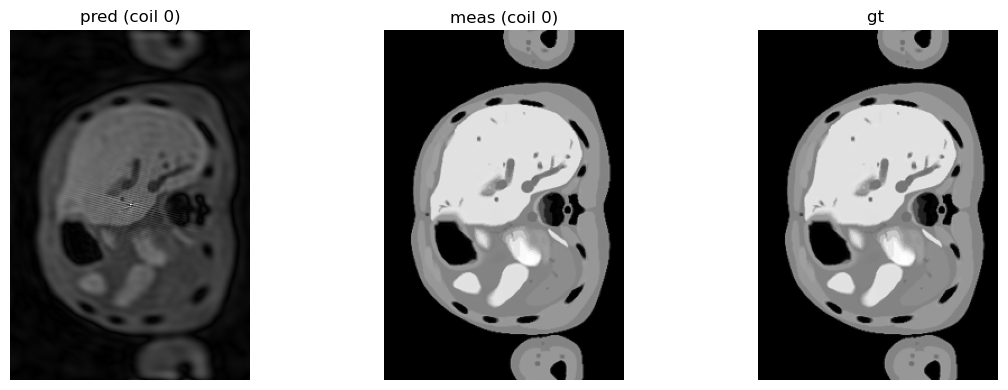

In [42]:
img_pred = np.abs(img_pred_c)
img_meas = np.abs(img_meas_c)
print('img_pred:', img_pred.shape, '  img_meas:', img_meas.shape)

gt = cart_event.get('gt_img')
img_gt = None
if gt is not None:
    print('gt_img:', gt.shape)
    # (n_gt, kz, x, y): center-time, z_cart
    img_gt = np.abs(gt[min(t_frame, gt.shape[0]-1), z_cart])

n_panels = 3 if img_gt is not None else 2
fig, ax = plt.subplots(1, n_panels, figsize=(4*n_panels, 4))
ax[0].imshow(img_pred, cmap='gray'); ax[0].set_title(f'pred (coil {coil_idx})'); ax[0].axis('off')
ax[1].imshow(img_meas, cmap='gray'); ax[1].set_title(f'meas (coil {coil_idx})'); ax[1].axis('off')
if img_gt is not None:
    ax[2].imshow(img_gt, cmap='gray'); ax[2].set_title('gt '); ax[2].axis('off')
plt.tight_layout(); plt.show()

## Pred with coil map

S_c: (312, 214)   img_pred_c: (312, 214)   img_meas_c: (312, 214)
0.10721064
0.10721064


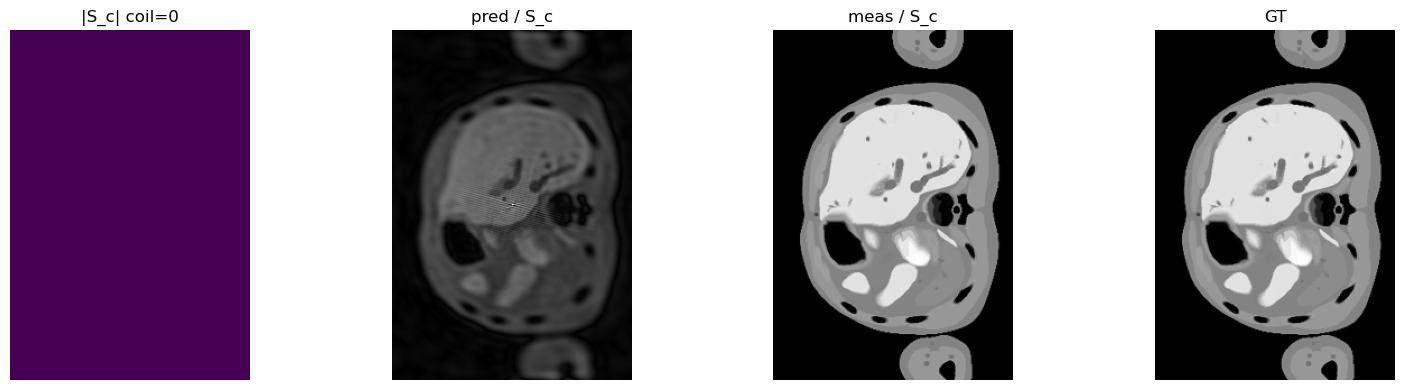

pred/S_c vs GT  max |diff|: 0.7668157815933228
meas/S_c vs GT  max |diff|: 0.000517508015036583


In [43]:
S_c = cart_event['coil_maps'][coil_idx, z_cart, :, :].astype(np.complex64)   # (312, 214)
print('S_c:', S_c.shape, '  img_pred_c:', img_pred_c.shape, '  img_meas_c:', img_meas_c.shape)

# single-coil sense
denom = np.abs(S_c)**2 + 1e-10
#img_pred_sense = np.abs(np.conj(S_c) * img_pred_c / denom)

print(denom.min())
print(denom.max())

img_pred_sense = np.abs(img_pred_c)
img_meas_sense = np.abs(np.conj(S_c) * img_meas_c / denom)
n = lambda a: a / (a.max() + 1e-12)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(np.abs(S_c), cmap='viridis'); ax[0].set_title(f'|S_c| coil={coil_idx}'); ax[0].axis('off')
ax[1].imshow(n(img_pred_sense), cmap='gray'); ax[1].set_title('pred / S_c'); ax[1].axis('off')
ax[2].imshow(n(img_meas_sense), cmap='gray'); ax[2].set_title('meas / S_c'); ax[2].axis('off')
ax[3].imshow(n(img_gt),         cmap='gray'); ax[3].set_title('GT');          ax[3].axis('off')
plt.tight_layout(); plt.show()

print('pred/S_c vs GT  max |diff|:', float(np.abs(n(img_pred_sense) - n(img_gt)).max()))
print('meas/S_c vs GT  max |diff|:', float(np.abs(n(img_meas_sense) - n(img_gt)).max()))

## Coil-map alignment (measured k-space → SENSE vs GT)

sens: (8, 312, 214)   coil_imgs: (8, 312, 214)


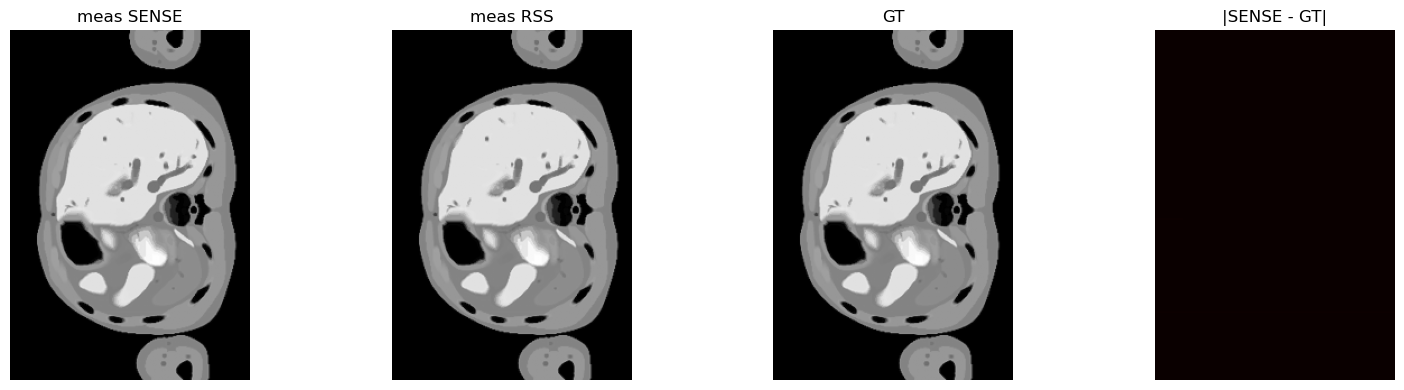

SENSE-GT max |diff|: 0.0004711747169494629
RSS-GT   max |diff|: 0.0004711747169494629


In [44]:
sens = cart_event['coil_maps'][:, z_cart, :, :].astype(np.complex64)   # (C, 312, 214)
k_c  = k_cart_z[min(t_frame, k_cart_z.shape[0]-1), :, z_cart, :, :].cpu().numpy()  # (C, 214, 312)

coil_imgs = np.fft.ifft2(k_c).transpose(0, 2, 1)                       # (C, 312, 214)
print('sens:', sens.shape, '  coil_imgs:', coil_imgs.shape)

denom    = np.sum(np.abs(sens)**2, axis=0) + 1e-10
img_sense = np.abs(np.sum(np.conj(sens) * coil_imgs, axis=0) / denom)
img_rss   = np.sqrt(np.sum(np.abs(coil_imgs)**2, axis=0))

gt = cart_event['gt_img']
img_gt = np.abs(gt[min(t_frame, gt.shape[0]-1), z_cart])
n = lambda a: a / (a.max() + 1e-12)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(n(img_sense), cmap='gray'); ax[0].set_title('meas SENSE'); ax[0].axis('off')
ax[1].imshow(n(img_rss),   cmap='gray'); ax[1].set_title('meas RSS');   ax[1].axis('off')
ax[2].imshow(n(img_gt),    cmap='gray'); ax[2].set_title('GT');          ax[2].axis('off')
ax[3].imshow(np.abs(n(img_sense) - n(img_gt)), cmap='hot', vmax=0.1)
ax[3].set_title('|SENSE - GT|'); ax[3].axis('off')
plt.tight_layout(); plt.show()

print('SENSE-GT max |diff|:', float(np.abs(n(img_sense) - n(img_gt)).max()))
print('RSS-GT   max |diff|:', float(np.abs(n(img_rss)   - n(img_gt)).max()))